In [ ]:
# Load data from CSV into DataFrame
import pandas as pd

# Load CSV file into DataFrame
df = pd.read_csv("../files/ragas_eval_result.csv")

# Display basic information about the DataFrame
print(f"DataFrame shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

# Display first few rows
df.head()

DataFrame shape: (207, 9)
Columns: ['question', 'factual_correctness', 'answer_accuracy', 'semantic_similarity', 'prompt_tokens', 'completion_tokens', 'total_tokens', 'duration_seconds', 'llm']


,question,factual_correctness,answer_accuracy,semantic_similarity,prompt_tokens,completion_tokens,total_tokens,duration_seconds,llm
0,What is the main focus of AstraZeneca's sustai...,0.00,0.00,0.926802,42899.0,5146.0,48045.0,103.87,deepseek
1,What are the three main areas of AstraZeneca's...,0.08,0.25,0.931793,65717.0,18606.0,84323.0,348.09,deepseek
2,What is AstraZeneca's target for reducing emis...,0.00,1.00,0.928066,43570.0,3915.0,47485.0,81.96,deepseek
3,What is AstraZeneca's commitment towards water...,0.40,0.50,0.940814,43595.0,6976.0,50571.0,142.40,deepseek
4,What is the My Green Lab Certification?,0.38,0.00,0.861589,57642.0,13906.0,71548.0,268.12,deepseek


In [7]:
# Tidy data

# Remove rows with 'AVERAGE' question value or empty question values
print(f"Original DataFrame shape: {df.shape}")

# Remove rows where question is 'AVERAGE' or empty/null
df_clean = df[
    (df["question"] != "AVERAGE")
    & (df["question"].notna())
    & (df["question"] != "")
    & (df["question"].str.strip() != "")
].copy()

print(f"Cleaned DataFrame shape: {df_clean.shape}")
print(f"Removed {df.shape[0] - df_clean.shape[0]} rows")

# Update df to use the cleaned version
df = df_clean

# Display first few rows of cleaned data
df.head()

Original DataFrame shape: (207, 9)
Cleaned DataFrame shape: (193, 9)
Removed 14 rows


,question,factual_correctness,answer_accuracy,semantic_similarity,prompt_tokens,completion_tokens,total_tokens,duration_seconds,llm
0,What is the main focus of AstraZeneca's sustai...,0.00,0.00,0.926802,42899.0,5146.0,48045.0,103.87,deepseek
1,What are the three main areas of AstraZeneca's...,0.08,0.25,0.931793,65717.0,18606.0,84323.0,348.09,deepseek
2,What is AstraZeneca's target for reducing emis...,0.00,1.00,0.928066,43570.0,3915.0,47485.0,81.96,deepseek
3,What is AstraZeneca's commitment towards water...,0.40,0.50,0.940814,43595.0,6976.0,50571.0,142.40,deepseek
4,What is the My Green Lab Certification?,0.38,0.00,0.861589,57642.0,13906.0,71548.0,268.12,deepseek


In [8]:
# Calculate and display average values for each LLM
print("Average Semantic Similarity Scores by LLM:")
print("=" * 45)

# Calculate averages for semantic_similarity by LLM
llm_averages = df.groupby("llm")["semantic_similarity"].mean().sort_values(ascending=False)

for llm, avg_score in llm_averages.items():
    print(f"{llm}: {avg_score:.4f}")

print("\nAll Metrics Averages by LLM:")
print("=" * 35)

# Calculate averages for all numeric columns by LLM
numeric_columns = df.select_dtypes(include=["number"]).columns
llm_all_averages = df.groupby("llm")[numeric_columns].mean()

# Display in a formatted table
print(llm_all_averages.round(4))

Average Semantic Similarity Scores by LLM:
qwen3-30b: 0.8952
deepseek: 0.8868
gpt-oss-20b: 0.8863
gpt-4o-mini: 0.8783
gpt-4o: 0.8680
gemma-3.1b: 0.8597
lfm2-1.2: 0.8533

All Metrics Averages by LLM:
             factual_correctness  answer_accuracy  semantic_similarity  \
llm                                                                      
deepseek                  0.1593           0.3793               0.8868   
gemma-3.1b                0.1934           0.0948               0.8597   
gpt-4o                    0.0782           0.2589               0.8680   
gpt-4o-mini               0.1396           0.2800               0.8783   
gpt-oss-20b               0.2052           0.4483               0.8863   
lfm2-1.2                  0.1379           0.1339               0.8533   
qwen3-30b                 0.2832           0.4000               0.8952   

             prompt_tokens  completion_tokens  total_tokens  duration_seconds  
llm                                                   

<Figure size 1200x600 with 0 Axes>

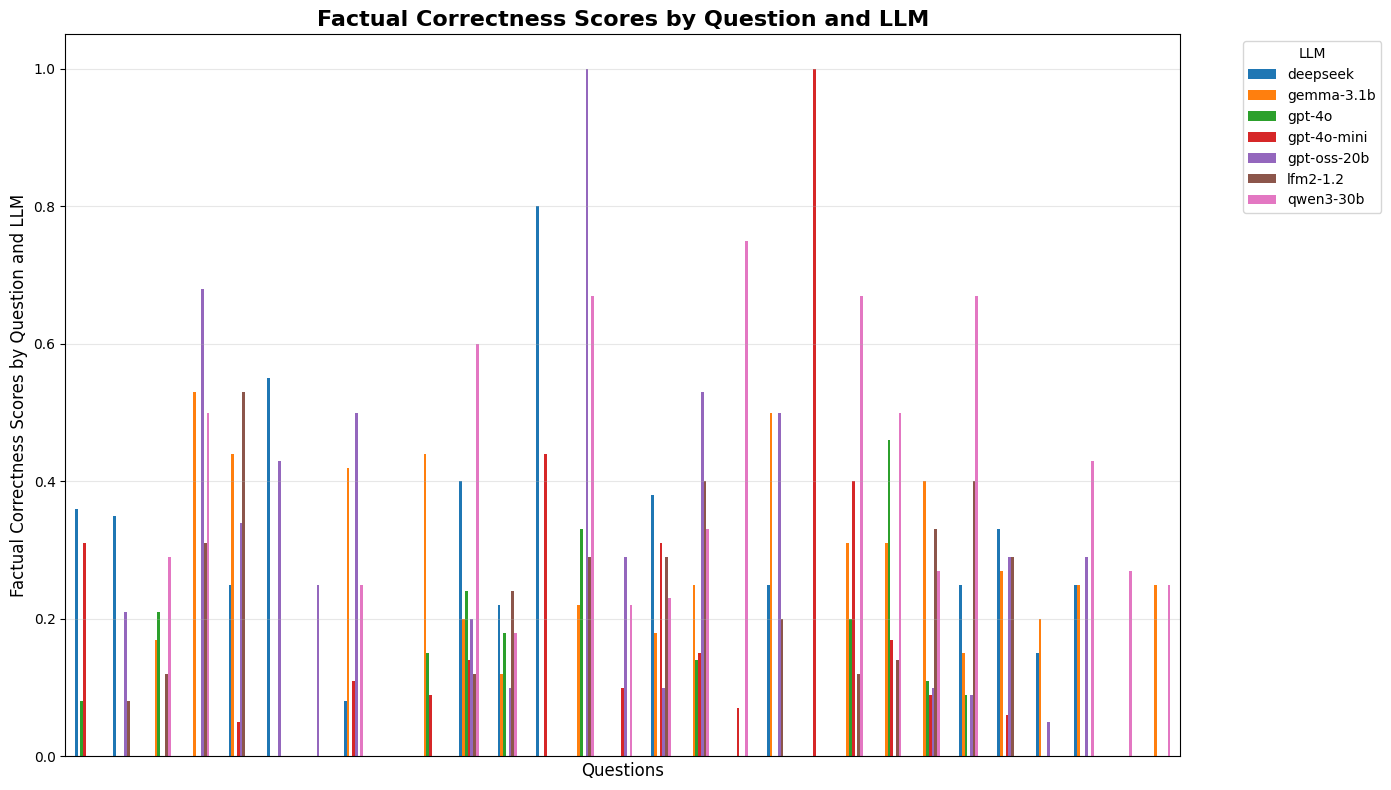

<Figure size 1200x600 with 0 Axes>

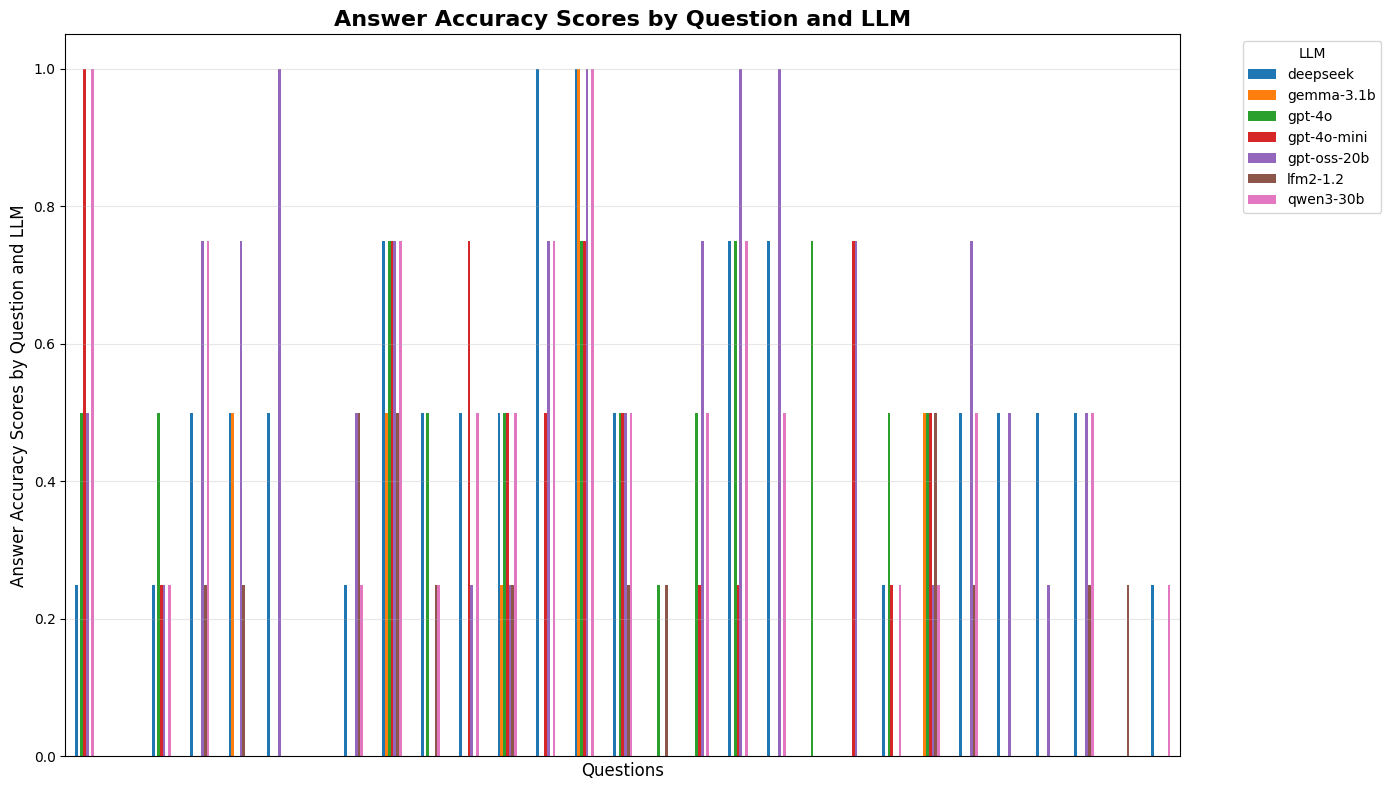

<Figure size 1200x600 with 0 Axes>

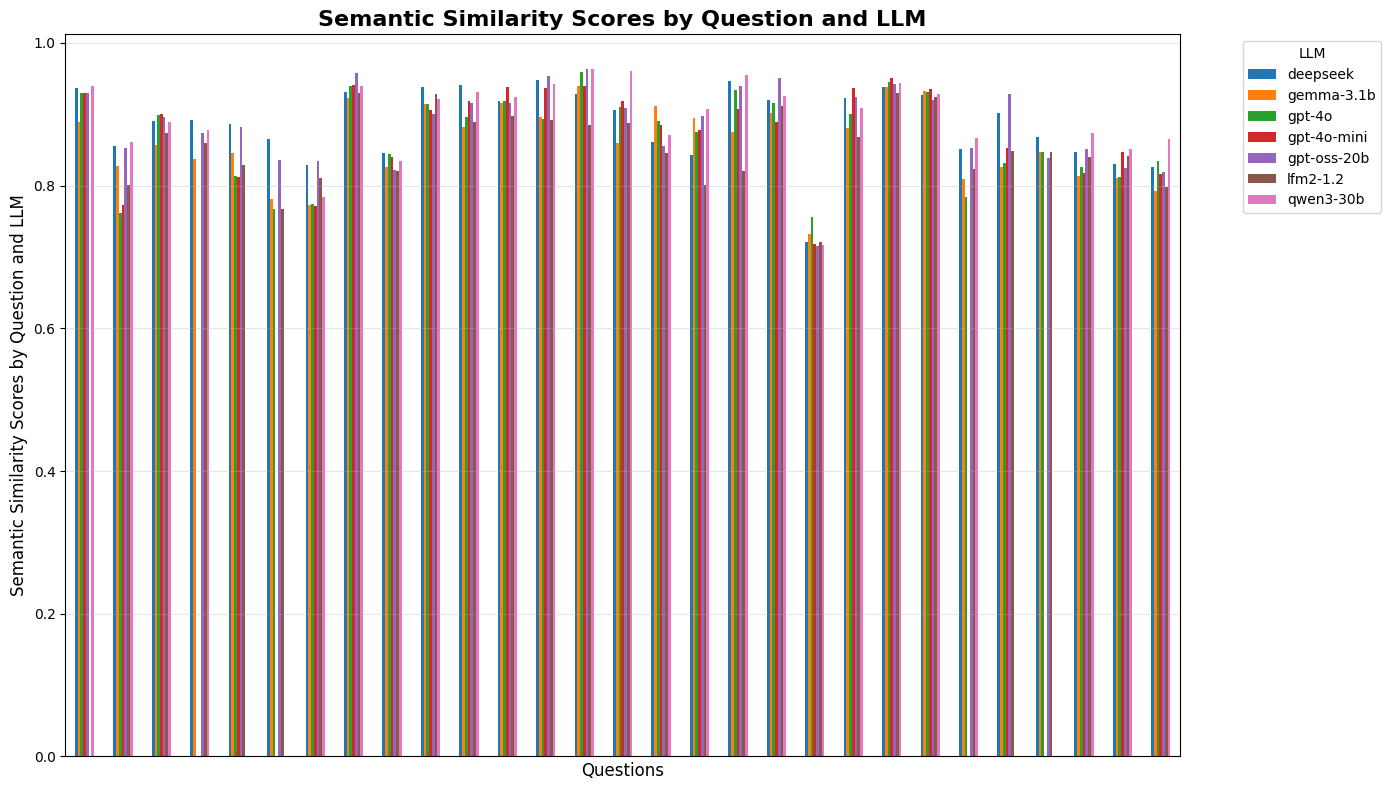

In [9]:
# Create visualizations using matplotlib
import matplotlib.pyplot as plt


def generate_chart(frame, key, title):
    # Set up the plot style
    plt.style.use("default")

    # Create column chart for semantic_similarity by question, grouped by LLM
    plt.figure(figsize=(12, 6))

    # Group by question and LLM, then plot
    pivot_data = frame.pivot(index="question", columns="llm", values=key)

    # Create grouped bar chart
    ax = pivot_data.plot(kind="bar", figsize=(14, 8))
    plt.title(title, fontsize=16, fontweight="bold")
    plt.xlabel("Questions", fontsize=12)
    plt.ylabel(title, fontsize=12)
    plt.xticks([])  # Hide x-axis text labels
    plt.legend(title="LLM", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.grid(axis="y", alpha=0.3)
    plt.show()  # Show each chart individually


generate_chart(df, "factual_correctness", "Factual Correctness Scores by Question and LLM")
generate_chart(df, "answer_accuracy", "Answer Accuracy Scores by Question and LLM")
generate_chart(df, "semantic_similarity", "Semantic Similarity Scores by Question and LLM")